In [2]:
import torch 
import torch.nn as nn
import torchvision.models as tv_models
import torchvision.transforms as transforms
import helper_utils

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using Device: {device}")

Using Device: cuda


In [5]:
emnist_transformation = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomRotation(degrees=(90, 90)),
    transforms.RandomVerticalFlip(p=1.0),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])    

In [6]:
train_loader, val_loader = helper_utils.create_emnist_dataloaders(
    batch_size = 32,
    transform = emnist_transformation
)

In [8]:
mobilenet_model = tv_models.mobilenet_v3_small(weights='IMAGENET1K_V1').eval()

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /home/jovyan/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 209MB/s]


In [9]:
class_names = helper_utils.load_imagenet_classes('./imagenet_class_index.json')

Loading ImageNet class index from: ./imagenet_class_index.json
Successfully loaded the class index.


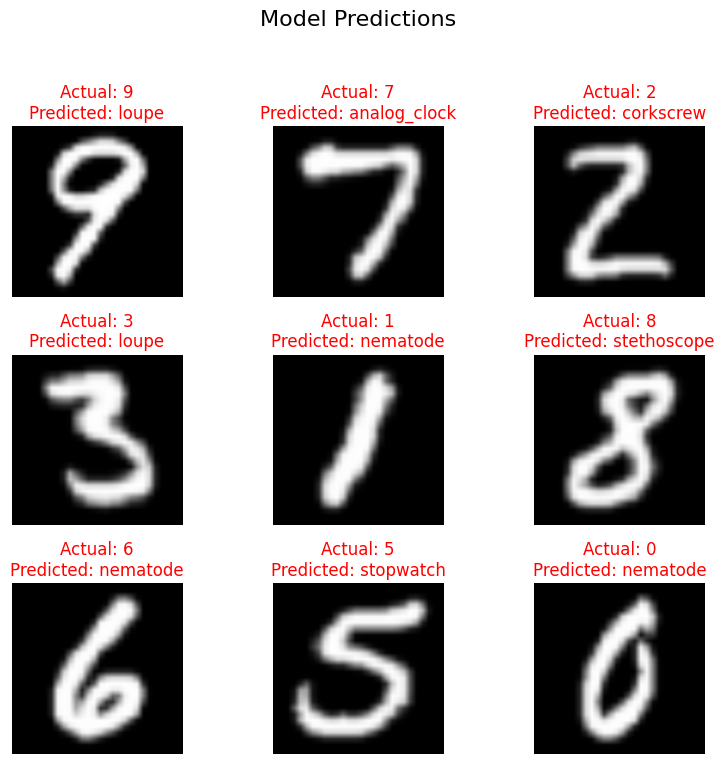

In [10]:
helper_utils.show_predictions(mobilenet_model, val_loader, device, class_names)

In [11]:
resnet18_model = tv_models.resnet18(weights='IMAGENET1K_V1')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/jovyan/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 230MB/s]


In [13]:
print(resnet18_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [14]:
for param in resnet18_model.parameters() :
    param.requires_grad = False

In [19]:
original_fc_layer = resnet18_model.fc

In [20]:
print("Model's Original Fully Connected Layer : ")
print(original_fc_layer)

Model's Original Fully Connected Layer : 
Linear(in_features=512, out_features=1000, bias=True)


In [22]:
num_features = original_fc_layer.in_features
num_classes = 5
new_fc_layer = nn.Linear(in_features=num_features, out_features=num_classes)
resnet18_model.fc = new_fc_layer
print("Model's New Fully Connected Layer : ", resnet18_model.fc)

Model's New Fully Connected Layer :  Linear(in_features=512, out_features=5, bias=True)


In [23]:
mobilenet_model = tv_models.mobilenet_v3_small(weights='IMAGENET1K_V1')

In [24]:
print(mobilenet_model)

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [25]:
for feature_parameter in mobilenet_model.features.parameters() :
    feature_parameter.requires_grad = False

In [29]:
last_classifier_layer = mobilenet_model.classifier[-1]
print("Model's Original Output Layer : ", last_classifier_layer)

Model's Original Output Layer :  Linear(in_features=1024, out_features=1000, bias=True)


In [32]:
num_features = last_classifier_layer.in_features
num_classes = 10
new_classifier = nn.Linear(in_features=num_features, out_features=num_classes)
mobilenet_model.classifier[-1] = new_classifier
print("Model's New Output Layer : ", mobilenet_model.classifier[-1])

Model's New Output Layer :  Linear(in_features=1024, out_features=10, bias=True)


In [34]:
loss_function = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(filter(lambda p: p.requires_grad, mobilenet_model.parameters()), lr=0.001)

In [35]:
num_epochs = 1

# Start the training.
trained_model = helper_utils.training_loop(
    model=mobilenet_model, 
    trainloader=train_loader, 
    valloader=val_loader, 
    loss_function=loss_function, 
    optimizer=optimizer, 
    num_epochs=num_epochs, 
    device=device
)

Epoch 1/1 [Train]:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/1 [Val]:   0%|          | 0/250 [00:00<?, ?it/s]


Finished Training!
Final Validation Accuracy: 0.8294


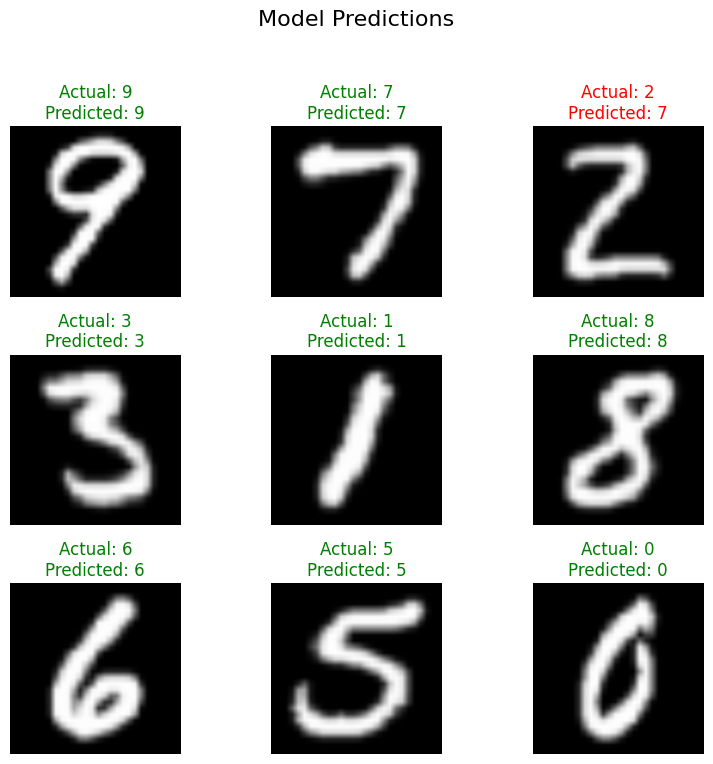

In [38]:
emnist_class_names = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
helper_utils.show_predictions(trained_model, val_loader, device, emnist_class_names)

In [39]:
print(trained_model)

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), 

In [41]:
finetune_model = trained_model
for param in finetune_model.features[12].parameters() :
    param.requires_grad = True

print(f"Parameters in features[0] are frozen : {not finetune_model.features[0][0].weight.requires_grad}")
print(f"Parameters in features[12] are unfrozen : {finetune_model.features[12][0].weight.requires_grad}")
print(f"Parameters in the classifier are unfrozen : {finetune_model.classifier[-1].weight.requires_grad}")

Parameters in features[0] are frozen : True
Parameters in features[12] are unfrozen : True
Parameters in the classifier are unfrozen : True


In [42]:
optimizer = torch.optim.SGD(
    filter(lambda p: p.requires_grad, finetune_model.parameters()),
    lr=1e-5
)

In [44]:
num_epochs_fine_tune = 1

fine_tune_trained_model = helper_utils.training_loop(
    model=finetune_model,
    trainloader=train_loader,
    valloader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    num_epochs=num_epochs_fine_tune,
    device=device
)

Epoch 1/1 [Train]:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/1 [Val]:   0%|          | 0/250 [00:00<?, ?it/s]


Finished Training!
Final Validation Accuracy: 0.8430


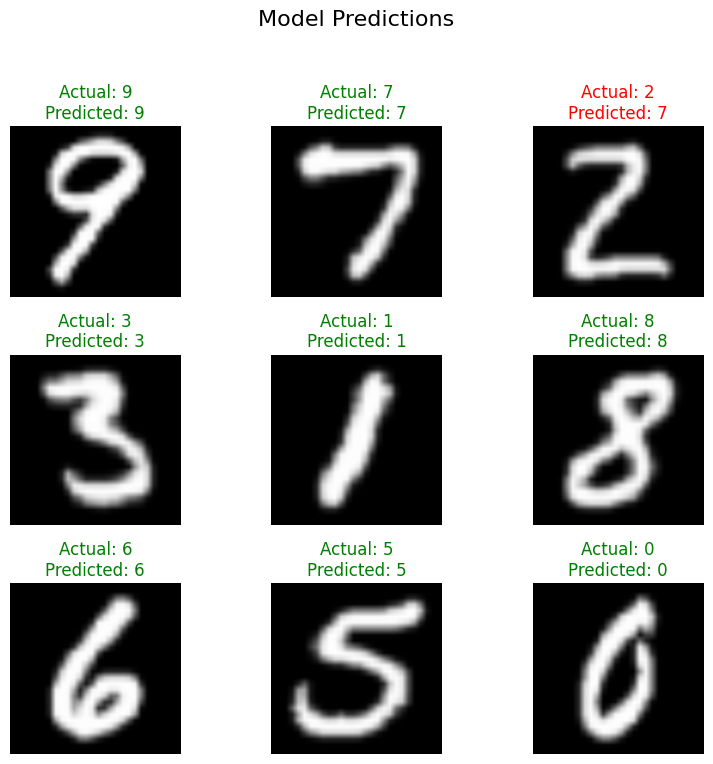

In [46]:
helper_utils.show_predictions(fine_tune_trained_model, val_loader, device, emnist_class_names)

In [47]:
full_retrain_model = fine_tune_trained_model

In [48]:
for param in full_retrain_model.parameters() :
    param.requires_grad = True

In [49]:
print(f"Parameters in features[0] are unfrozen: {full_retrain_model.features[0][0].weight.requires_grad}")

Parameters in features[0] are unfrozen: True


In [50]:
optimizer = torch.optim.SGD(
    full_retrain_model.parameters(),
    lr=1e-4
)

In [51]:
num_epochs_full_retrain = 1

final_model = helper_utils.training_loop(
    model=full_retrain_model,
    trainloader=train_loader,
    valloader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    num_epochs=num_epochs_full_retrain,
    device=device
)

Epoch 1/1 [Train]:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1/1 [Val]:   0%|          | 0/250 [00:00<?, ?it/s]


Finished Training!
Final Validation Accuracy: 0.8388


In [ ]:
helper_utils.show_predictions(final_model, val_loader, device, emnist_class_names)